# Week 1 Student Performance Dataset Analysis

AI&ML Internship – WeIntern Pvt Ltd

Name: Yogesh Negi

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("StudentsPerformance.csv")

In [5]:
df.head()

,Student ID,Gender,Age,Attendance Percentage,Study Hours Per Week,Assignment Score,Midterm Score,Final Score,Parental Education,Internet Access,Extra Activities
0,S0064,F,18,92.8,NaN,46.7,NaN,72.3,NaN,YES,N
1,S0061,NaN,18,49.9,1.0,34.3,26.9,38.9,Bachelor's Degree,Yes,No
2,S0005,NaN,19,83.0,17.9,54.3,95.5,51.7,phd,Yes,N
3,S0097,Male,15,55.5,10.8,81.8,82.1,61.3,Associate Degree,No,NO
4,S0177,NaN,21,53.4,16.8,79.4,58.2,56.8,High School,NO,yes


In [6]:
df.tail()

,Student ID,Gender,Age,Attendance Percentage,Study Hours Per Week,Assignment Score,Midterm Score,Final Score,Parental Education,Internet Access,Extra Activities
201,S0070,male,21,98.9,13.0,96.1,34.5,69.6,phd,NO,Yes
202,S0131,M,17,72.8,19.4,74.6,65.8,105.0,High School,No,NO
203,S0081,female,22,81.6,11.1,81.9,57.9,91.2,masters,Yes,YES
204,S0155,male,18,64.1,19.6,95.6,71.8,34.2,masters,YES,no
205,S0198,M,20,76.1,7.8,98.6,91.4,90.7,Associate Degree,YES,Y


In [7]:
#Dataset Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (206, 11)


In [8]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student ID             206 non-null    object 
 1   Gender                 193 non-null    object 
 2   Age                    206 non-null    int64  
 3   Attendance Percentage  194 non-null    float64
 4   Study Hours Per Week   189 non-null    float64
 5   Assignment Score       206 non-null    float64
 6   Midterm Score          199 non-null    float64
 7   Final Score            206 non-null    float64
 8   Parental Education     162 non-null    object 
 9   Internet Access        192 non-null    object 
 10  Extra Activities       206 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 17.8+ KB


Feature Understanding Table


| Feature               | Type        | Description                 |
| --------------------- | ----------- | --------------------------- |
| Student ID            | Identifier  | Unique student ID           |
| Gender                | Categorical | Student gender              |
| Age                   | Numerical   | Student age                 |
| Attendance Percentage | Numerical   | Attendance percentage       |
| Study Hours Per Week  | Numerical   | Weekly study hours          |
| Assignment Score      | Numerical   | Assignment marks            |
| Midterm Score         | Numerical   | Midterm marks               |
| Final Score           | Numerical   | Final examination marks     |
| Parental Education    | Categorical | Parent education level      |
| Internet Access       | Categorical | Internet availability       |
| Extra Activities      | Categorical | Participation in activities |


In [9]:
#missing values
df.isnull().sum()

,0
Student ID,0
Gender,13
Age,0
Attendance Percentage,12
Study Hours Per Week,17
Assignment Score,0
Midterm Score,7
Final Score,0
Parental Education,44
Internet Access,14


In [10]:
# Check for duplicated rows
print('Number of duplicated rows:', df.duplicated().sum())

Number of duplicated rows: 6


Cleaning Dataset


In [11]:
#Remove duplicates
df = df.drop_duplicates()

In [12]:
#Fill Gender
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [13]:
#Fill Attendance
df["Attendance Percentage"] = df["Attendance Percentage"].fillna(
    df["Attendance Percentage"].median()
)

In [14]:
#Fill Study Hours
df["Study Hours Per Week"] = df["Study Hours Per Week"].fillna(
    df["Study Hours Per Week"].median()
)

In [15]:
#Fill Midterm Score
df["Midterm Score"] = df["Midterm Score"].fillna(
    df["Midterm Score"].median()
)

In [16]:
#Fill Parental Education
df["Parental Education"] = df["Parental Education"].fillna(
    df["Parental Education"].mode()[0]
)

In [17]:
#Fill Internet Access
df["Internet Access"] = df["Internet Access"].fillna(
    df["Internet Access"].mode()[0]
)

In [18]:
#Cleaned dataset
df.isnull().sum()

,0
Student ID,0
Gender,0
Age,0
Attendance Percentage,0
Study Hours Per Week,0
Assignment Score,0
Midterm Score,0
Final Score,0
Parental Education,0
Internet Access,0


All values are now showing 0.

In [19]:
df.to_csv("cleaned_student_performance.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [20]:
df.describe()

,Age,Attendance Percentage,Study Hours Per Week,Assignment Score,Midterm Score,Final Score
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,20.100000,68.914000,10.172500,82.151000,62.073500,59.607500
std,14.505587,18.016616,5.410291,115.333739,20.748662,21.814367
min,5.000000,40.100000,1.000000,-5.000000,25.300000,-10.000000
25%,17.000000,53.700000,5.475000,49.775000,44.975000,43.175000
50%,19.000000,67.450000,10.400000,69.800000,62.500000,56.500000
75%,21.000000,85.175000,14.475000,86.350000,78.925000,77.450000
max,150.000000,99.900000,20.000000,999.000000,99.500000,105.000000


In [21]:
# Keep only realistic values

df = df[(df["Age"] >= 5) & (df["Age"] <= 30)]

df = df[(df["Assignment Score"] >= 0) & (df["Assignment Score"] <= 100)]

df = df[(df["Final Score"] >= 0) & (df["Final Score"] <= 100)]

In [22]:
df.describe()

,Age,Attendance Percentage,Study Hours Per Week,Assignment Score,Midterm Score,Final Score
count,189.000000,189.000000,189.000000,189.00000,189.000000,189.000000
mean,18.449735,69.181746,10.057672,68.16455,62.594709,59.275661
std,2.419746,18.063161,5.364789,20.47416,20.950201,20.724439
min,5.000000,40.100000,1.000000,31.00000,25.300000,25.300000
25%,17.000000,54.100000,5.300000,49.70000,45.600000,43.200000
50%,19.000000,67.450000,10.400000,69.00000,62.500000,56.500000
75%,21.000000,86.300000,14.200000,85.50000,79.500000,76.000000
max,22.000000,99.900000,20.000000,99.60000,99.500000,99.600000


In [23]:
df.to_csv("cleaned_student_performance.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


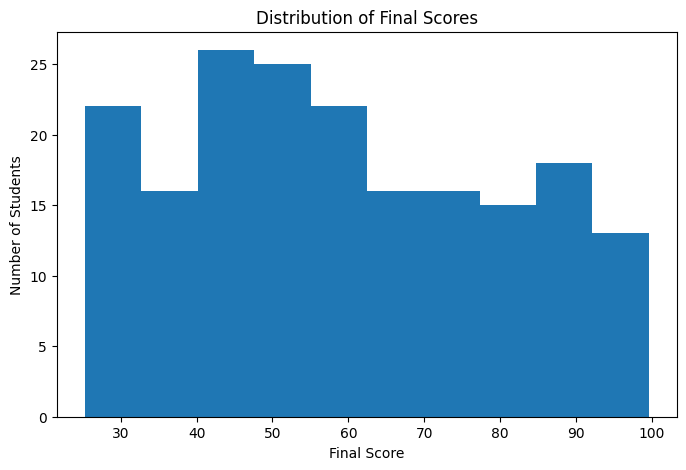

In [24]:
#histogram
plt.figure(figsize=(8,5))
plt.hist(df["Final Score"], bins=10)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "male": "Male",
    "MALE": "Male",
    "F": "Female",
    "female": "Female",
    "FEMALE": "Female"
})

In [27]:
print(df["Gender"].value_counts())

Gender
Female    106
Male       83
Name: count, dtype: int64


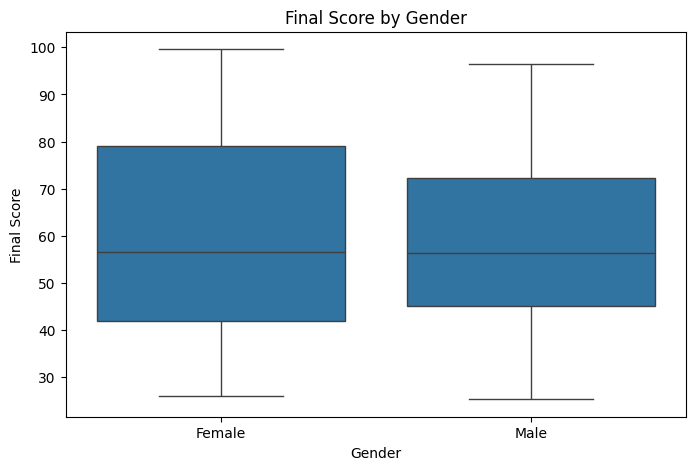

In [28]:
#box plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Gender", y="Final Score", data=df)

plt.title("Final Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Final Score")

plt.show()

Observation:

The box plot compares the final score distribution between male and female students. The median scores for both groups are very similar, indicating comparable academic performance. Female students show a slightly wider spread of scores, but overall there is no significant difference in performance based on gender.

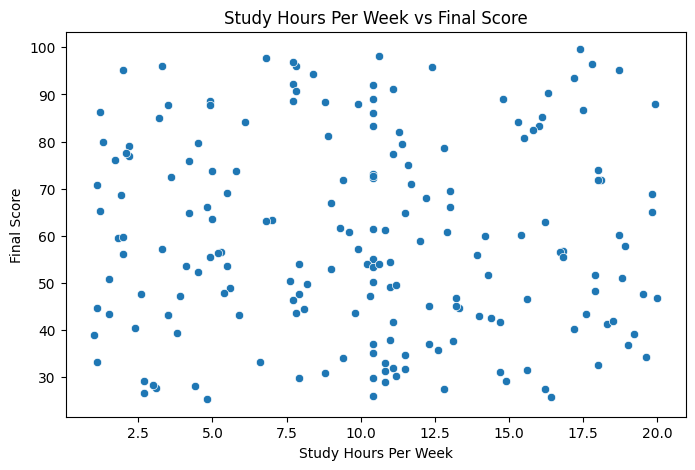

In [29]:
#scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Study Hours Per Week",
    y="Final Score",
    data=df
)

plt.title("Study Hours Per Week vs Final Score")
plt.xlabel("Study Hours Per Week")
plt.ylabel("Final Score")

plt.show()

Observation:

The scatter plot illustrates the relationship between study hours per week and final score. The data points are widely scattered, indicating a weak relationship between study time and academic performance. While some students who study more achieve higher scores, others do not, suggesting that factors such as attendance, assignment performance, and individual learning ability may also influence final results.

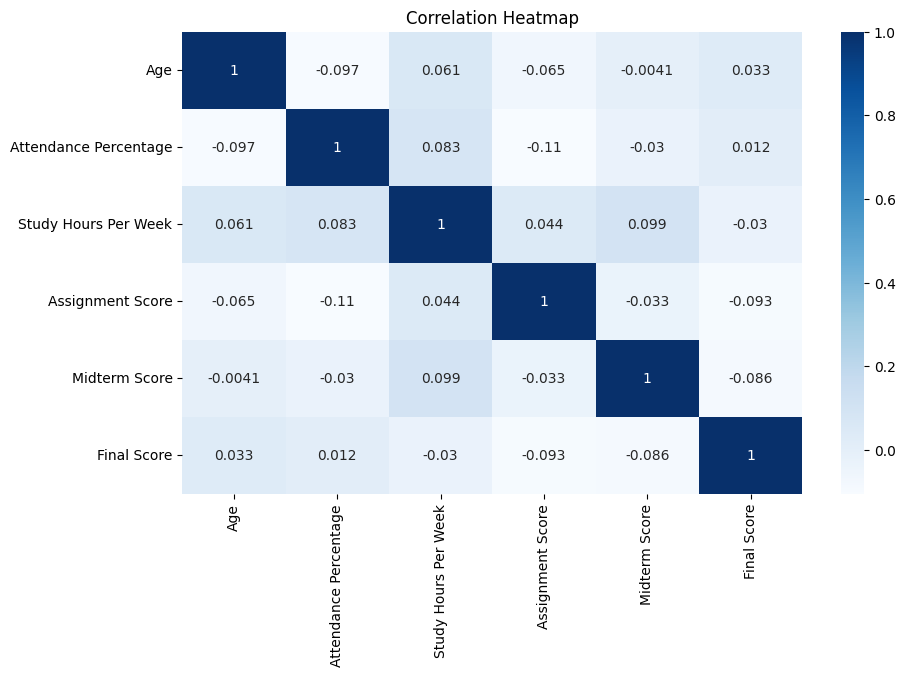

In [30]:
#heatmap
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

Observation:

The correlation heatmap shows the relationships between numerical variables in the dataset. Most correlation values are close to zero, indicating weak relationships among the variables. Study Hours Per Week shows a very weak positive relationship with Midterm Score, while Attendance Percentage has almost no correlation with Final Score. These results suggest that student performance may be influenced by multiple factors rather than a single variable.

In [31]:
df.to_csv("cleaned_student_performance.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
